# A classification problem

In [1]:
# Import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# Import the dataset
df_iris = pd.read_csv('Iris_dataset.csv')

In [3]:
#check the first 5 data
df_iris.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [16]:
# checking the shape of the data
print(f'The column size: {len(df_iris.columns)} and rows size: {len(df_iris)}')
#df_iris.shape
#len(df_iris)

The column size: 6 and rows size: 150


In [19]:
# check for missing value
print('=' *60)
print('Here is the general info about the data')
print('=' *60) 
print(df_iris.info())

Here is the general info about the data
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB
None


In [21]:
#missing value chek=ck again
print('=' *60)
print('This sums up all the null in the dataset')
print('=' *60) 
df_iris.isnull().sum()

This sums up all the null in the dataset


Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [24]:
print('=' *100)
print('Here is the statistical description of the dataset')
print('=' *100) 
print(df_iris.describe().T)

Here is the statistical description of the dataset
               count       mean        std  min    25%    50%     75%    max
Id             150.0  75.500000  43.445368  1.0  38.25  75.50  112.75  150.0
SepalLengthCm  150.0   5.843333   0.828066  4.3   5.10   5.80    6.40    7.9
SepalWidthCm   150.0   3.054000   0.433594  2.0   2.80   3.00    3.30    4.4
PetalLengthCm  150.0   3.758667   1.764420  1.0   1.60   4.35    5.10    6.9
PetalWidthCm   150.0   1.198667   0.763161  0.1   0.30   1.30    1.80    2.5


In [27]:
# Count each values in the target variable
df_iris['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

## Exploratory Data Analysis

In [30]:
#check the columns name
df_iris.columns.to_list()

['Id',
 'SepalLengthCm',
 'SepalWidthCm',
 'PetalLengthCm',
 'PetalWidthCm',
 'Species']

Text(0.5, 1.02, 'Iris Dataset - Pairplot')

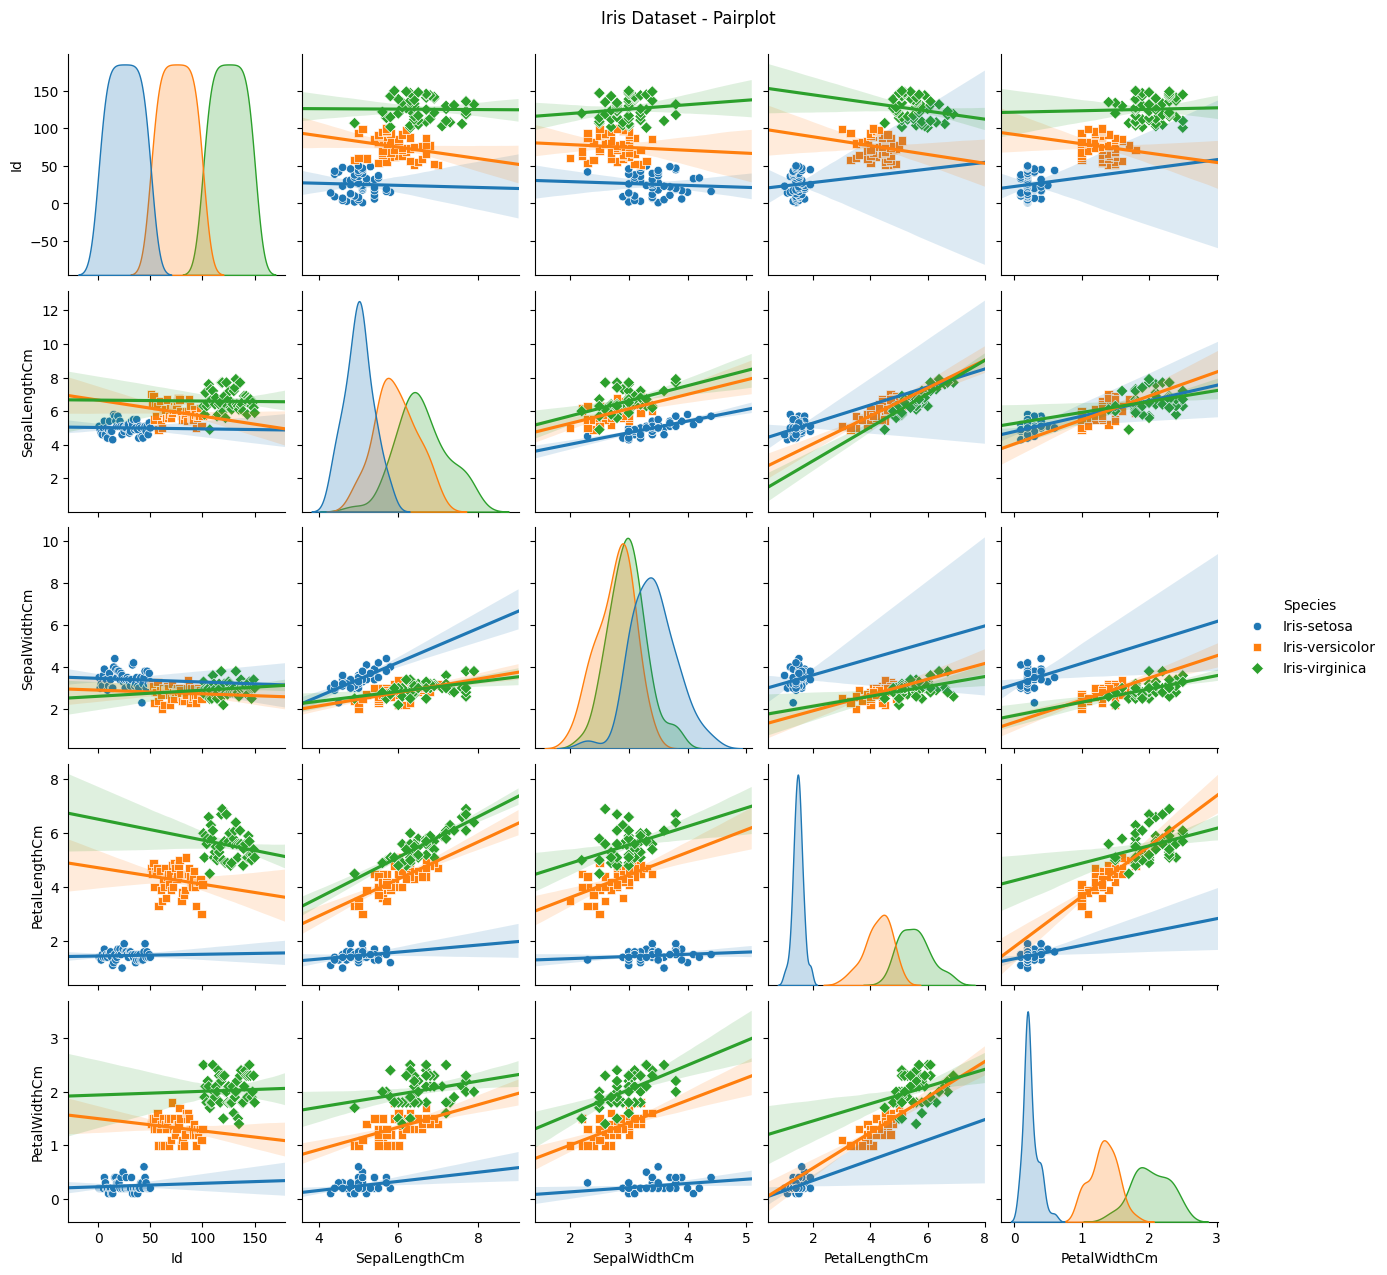

In [33]:
#Checking the relationships between features
sns.pairplot(df_iris, hue= 'Species',markers=['o','s','D']).map_offdiag(sns.regplot, scatter=False, truncate=False)
plt.suptitle('Iris Dataset - Pairplot', y=1.02)

Observations from pairplot
- petalelegth and petalwidth iri-satosa is sepearted from others om the diagonal
- There is regression line, some strongly correlated
- datapoints are clustered


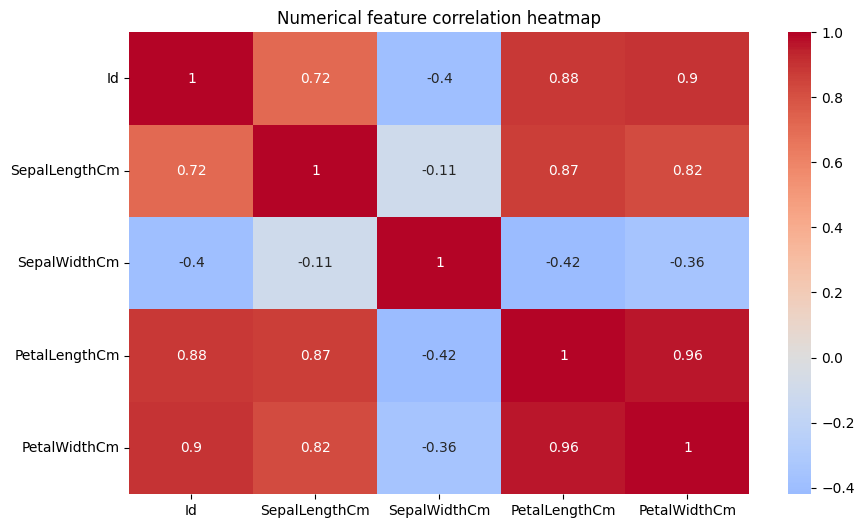

In [36]:
#Check correlation heatmap
plt.figure(figsize = (10,6))
#select numerical features only
numeric_col = df_iris.select_dtypes(include=[np.number]).columns
#plot
sns.heatmap(df_iris[numeric_col].corr(), annot=True, cmap='coolwarm', center = 0)
plt.title('Numerical feature correlation heatmap')
plt.show()

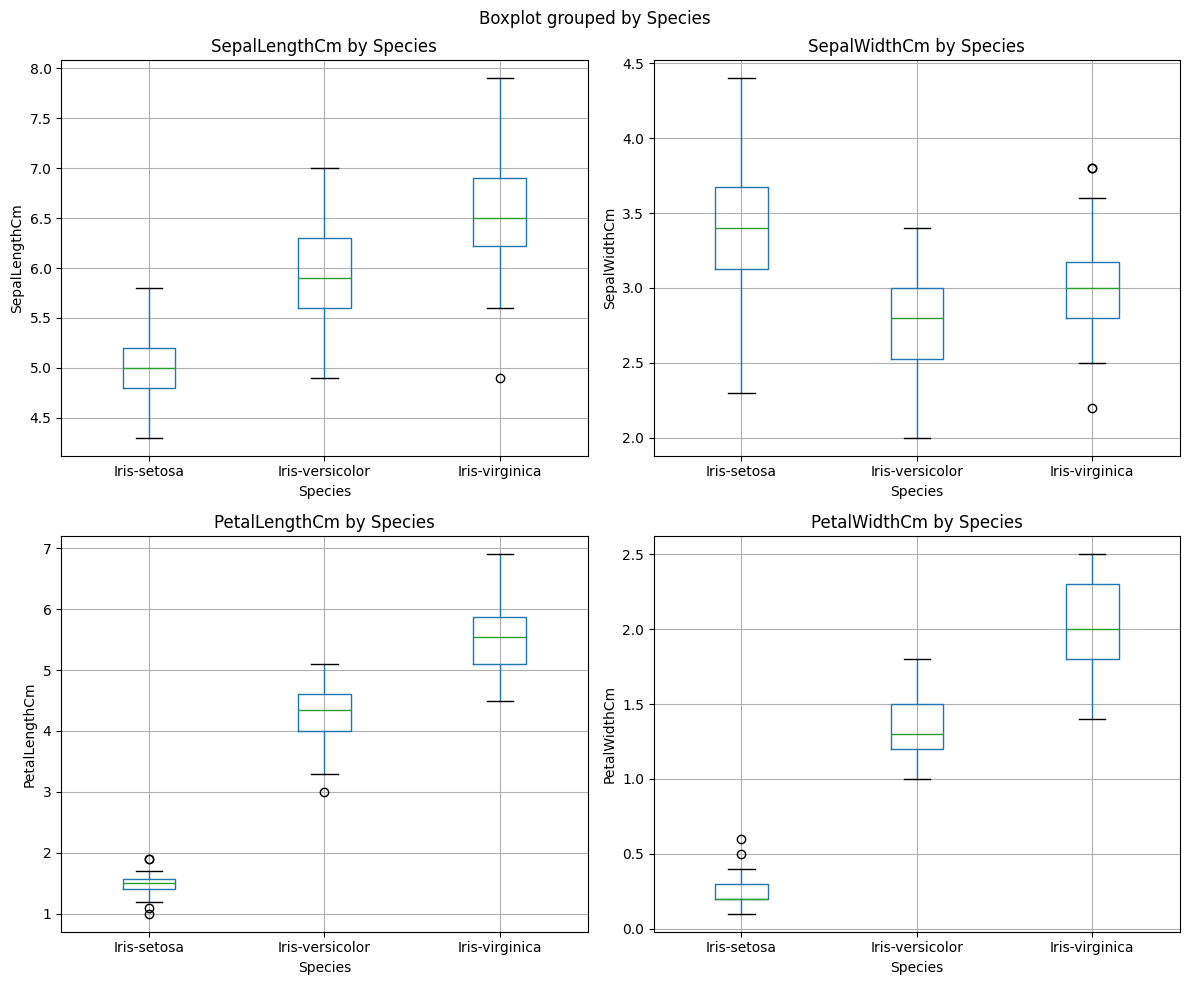

In [37]:
#Checking feature distribution by the class using boxplot
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
features = [col for col in df_iris.columns if col not in ['Id', 'Species']]

for idx, feature in enumerate(features):
    ax = axes[idx // 2, idx % 2]
    df_iris.boxplot(column=feature, by='Species', ax=ax)
    ax.set_title(f'{feature} by Species')
    ax.set_xlabel('Species')
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()

### Feature Selection

>
>
>
>
>

> - i
> - 2
> - 3
> - 4
> - 5




In [38]:
df_iris.columns.tolist()

['Id',
 'SepalLengthCm',
 'SepalWidthCm',
 'PetalLengthCm',
 'PetalWidthCm',
 'Species']

In [39]:
#selecting the target variable and the independent features
X = df_iris.drop(columns=['Id', 'Species'])
y = df_iris['Species']

In [51]:
#Let's see the feature
print('=' * 30)
print('Independent features (X):')
print('=' * 30)
print(X.head())
#print('')
print('\nThe Shape of X:', X.shape) #shape of independent variable
print('')
#The label feature
print('=' * 30)
print('Target feature (y):')
print('=' * 30)
print(y.head())
#print('')
print('\nThe Shape of y:', y.shape) #shape of independent variable

# Check the uniques values of the target variable
print('')
print('The unique values in the target variable are:', df_iris.Species.unique().tolist())

Independent features (X):
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0            5.1           3.5            1.4           0.2
1            4.9           3.0            1.4           0.2
2            4.7           3.2            1.3           0.2
3            4.6           3.1            1.5           0.2
4            5.0           3.6            1.4           0.2

The Shape of X: (150, 4)

Target feature (y):
0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: Species, dtype: str

The Shape of y: (150,)

The unique values in the target variable are: ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']


### Dataset splitting

In [57]:
# stratify=y ensures that the proportion of each class in the 
# target variable (y) is preserved in both splits.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state= 234, stratify=y
    )

#check the split
print(f'The size of X_train: {X_train.shape} \nThe size of X_test: {X_test.shape}')
print('')
# check the value count
print(f'The value count of each class in the y_train set:', y_train.value_counts())
print('')
print(f'The value count of each class in the y_test set:', y_test.value_counts())


The size of X_train: (120, 4) 
The size of X_test: (30, 4)

The value count of each class in the y_train set: Species
Iris-virginica     40
Iris-setosa        40
Iris-versicolor    40
Name: count, dtype: int64

The value count of each class in the y_test set: Species
Iris-virginica     10
Iris-versicolor    10
Iris-setosa        10
Name: count, dtype: int64


### Feature Scaling

In [94]:
# it is good to always scale the independent featurs
# we will scale using StandardScalar() method
scalar = StandardScaler()

# we fit on train data, and transform  both the train and test data
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

#convert the scaled array to dataframe
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns = X_train.columns) 
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns = X_test.columns)
print(
    f' The Original trained X:\n{X_train.head()} \n \
    The scaled trained X:\n \
    {X_train_scaled_df.head()} \n \
    The original test X:\n {X_test.head()} \n \
    The scaled test X: \n {X_test_scaled_df.head()}'
    )
#checking the mean and std of the scaled data, the mean  ust be closer to zero
# and std closer to 1
print('\n\n')
print(f'The mean of scaled trained X is: \n {X_train_scaled_df.mean()}\n\
      While the STD is: \n {X_train_scaled_df.std()}\
      ')


 The Original trained X:
     SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
136            6.3           3.4            5.6           2.4
138            6.0           3.0            4.8           1.8
32             5.2           4.1            1.5           0.1
135            7.7           3.0            6.1           2.3
148            6.2           3.4            5.4           2.3 
     The scaled trained X:
        SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0       0.595871      0.786810       1.050914      1.547506
1       0.222804     -0.116704       0.596874      0.770516
2      -0.772041      2.367960      -1.276042     -1.430958
3       2.336850     -0.116704       1.334689      1.418008
4       0.471515      0.786810       0.937404      1.418008 
     The original test X:
      SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
142            5.8           2.7            5.1           1.9
130            7.4           2.8            6.1           

## Model Training

In [100]:
print('Model in Training.....................')
model = LogisticRegression (random_state=234, max_iter=200)
print('\n\n')
print('Model training completed')
model.fit(X_train_scaled, y_train)


Model in Training.....................



Model training completed


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",234
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mult

### Make prediction

In [112]:
prediction = model.predict(X_test_scaled)

print(f'Logistic regression prediction (Top 10): \n{prediction [:10]}\n\n \
    Actual values (Top 10): \n{y_test.values[:10]}\
      ')

Logistic regression prediction (Top 10): 
['Iris-virginica' 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica'
 'Iris-virginica' 'Iris-setosa' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-setosa']

     Actual values (Top 10): 
<StringArray>
[ 'Iris-virginica',  'Iris-virginica', 'Iris-versicolor',  'Iris-virginica',
  'Iris-virginica',     'Iris-setosa', 'Iris-versicolor',  'Iris-virginica',
     'Iris-setosa',     'Iris-setosa']
Length: 10, dtype: str      


## Evaluating the model

#Logistic model step
#split your feature
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=234, stratify=y)
#scale X features
scaler = StandardScaler()
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)
#train model
model =LogisticRegression(random_state=234, max_iter=200)
model.fit(X_train, y_train)
#make prediction
prediction = model.predict(X_test)

In [121]:
# Calculate the accuracy
accuracy = accuracy_score(y_test, prediction)
print(f'The accuracy of the model is {accuracy:.2f}, in percentage is {(accuracy*100):.1f}% ')

The accuracy of the model is 0.93, in percentage is 93.3% 


In [128]:
#Detailed classification model report
c_report = classification_report(y_test, prediction)
print('=' * 50)
print ('Classfication detailed report')
print('=' * 50)
print(c_report)

Classfication detailed report
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



- accuracy score: general prediction score
- precision: how many FP 
- recall: how many FN
- f1 score: balance between precision and recall

#### Confusion matrix and plot to visualise


In [131]:
conf_matrix = confusion_matrix(y_test, prediction)
print(f'The confusion matrix is:\n {conf_matrix}')

The confusion matrix is:
 [[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


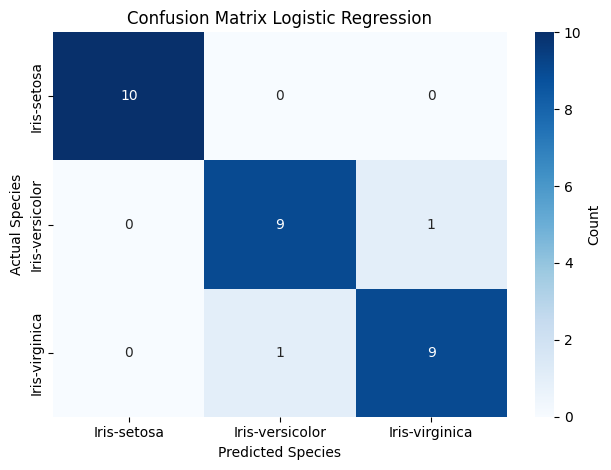

In [135]:
#visualising the confusion matrix
plt.Figure(figsize=(7,5))
species_names = sorted(y_test.unique())
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=species_names,
            yticklabels=species_names,
            cbar_kws={'label': 'Count'})
plt.ylabel('Actual Species')
plt.xlabel('Predicted Species')
plt.title(f'Confusion Matrix Logistic Regression')
plt.tight_layout()
plt.show()

### Saving model



In [136]:
import joblib
#model_filename = 'trained_iris_model.pkl'

# save the best model
joblib.dump(model, 'trained_iris_model.pkl')
print(f'Model saved as trained_iris_model.pkl')

# save the scalar too
joblib.dump(scalar, 'iris_scalar.pkl' )
print(f'Scalar saved as iris_scalar.pkl')

Model saved as trained_iris_model.pkl
Scalar saved as iris_scalar.pkl


In [138]:
# Retrieveing the model
model_filename = 'trained_iris_model.pkl'
scalar_filename = 'iris_scalar.pkl'

loaded_model = joblib.load(model_filename)
loaded_scaler = joblib.load(scalar_filename)
print("\nModel and scaler loaded successfully!")

# Verify it works by making a test prediction
test_prediction = loaded_model.predict(loaded_scaler.transform(X_test[:5])) #scales the X_test and print out first 5
print("\nTest predictions with loaded model:")
print(test_prediction)

print("\nActual values:")
print(y_test[:5].values) 


Model and scaler loaded successfully!

Test predictions with loaded model:
['Iris-virginica' 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica'
 'Iris-virginica']

Actual values:
<StringArray>
[ 'Iris-virginica',  'Iris-virginica', 'Iris-versicolor',  'Iris-virginica',
  'Iris-virginica']
Length: 5, dtype: str


#### This completes my lesson for a classification problem